# Финальные выводы и рекомендации

## Цель
Собрать все выводы из EDA и проверки гипотез. Сформулировать бизнес-рекомендации.

## Ключевые выводы

### 1. Категории
- Technology - лидер по сумме (825 856) и среднему чеку (456).
- Office Supplies - лидер по количеству (5903), но средний чек низкий (119).
- Furniture - середина.

### 2. Регионы
- West - лидер по сумме (710 000).
- South - аутсайдер (390 000).
- Средний чек одинаков во всех регионах (p = 0.49).

### 3. Сегменты
- Consumer - лидер по сумме (1 150 000).
- Home Office - аутсайдер (430 000).
- Средний чек одинаков (p = 0.59).

### 4. Доставка
- Standard Class - самый популярный.
- В понедельник - пик First Class и Same Day.
- В четверг - провал.
- В West и East - чаще First Class.

### 5. Сезонность
- Пик - сентябрь–декабрь.
- Статистически не подтверждена (p = 0.27).
- Визуально видна.

## Бизнес-рекомендации

### 1. Фокус на Technology
Technology - лидер по сумме продаж (825 856) и по среднему чеку (456). Категория приносит больше всего выручки. Рекомендуется:
- Увеличить ассортимент Technology.
- Сделать Technology ключевой категорией в маркетинге.
- Не забывать о развитии Furniture и Office Supplies для диверсификации.

### 2. Развитие отстающих регионов
South - самый слабый регион (390 000). Home Office - самый слабый сегмент (430 000). Рекомендуется:
- Увеличить маркетинговую активность в South.
- Стимулировать Home Office скидками и спецпредложениями.
- Проверить логистику в South: возможно, доставка дороже или дольше.

### 3. Оптимизация доставки
- В West и East клиенты чаще выбирают First Class - регионы платёжеспособны. Поддерживать и развивать.
- В Central и South преобладает Standard Class - клиенты экономят. Стимулировать First Class скидками.
- В понедельник - пик First Class и Same Day. Увеличить ресурсы на быструю доставку.
- В четверг - провал по всем типам доставки. Оптимизировать операционные расходы.

### 4. Сезонность и запасы
- Пик продаж - сентябрь–декабрь. Увеличить запасы и ресурсы в этот период.
- Сезонность не подтверждена статистически (p = 0.27), но видна визуально.
- В высокий сезон обратить внимание на ценообразование и скидки на залежавшиеся товары.

### 5. Сегменты и средний чек
- Средний чек не зависит от сегмента (p = 0.59). Не нужно разрабатывать отдельные стратегии по сегментам для увеличения чека.
- Consumer - лидер по количеству заказов. Фокус на удержании.
- Corporate и Home Office - потенциал для роста.

## Ограничения анализа
- Нет данных о Profit и Discount.
- Нет возможности проверить убыточность и влияние скидок.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/processed/superstore_clean.csv', parse_dates=['Order Date', 'Ship Date'])
print(df.head())
print(df.shape)

   Row ID        Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
1       2  CA-2017-152156 2017-11-08 2017-11-11    Second Class    CG-12520   
2       3  CA-2017-138688 2017-06-12 2017-06-16    Second Class    DV-13045   
3       4  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   
4       5  US-2016-108966 2016-10-11 2016-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

          Category  Sub-Category  \
0        Furniture     Bookcases   
1        Furniture        Chairs

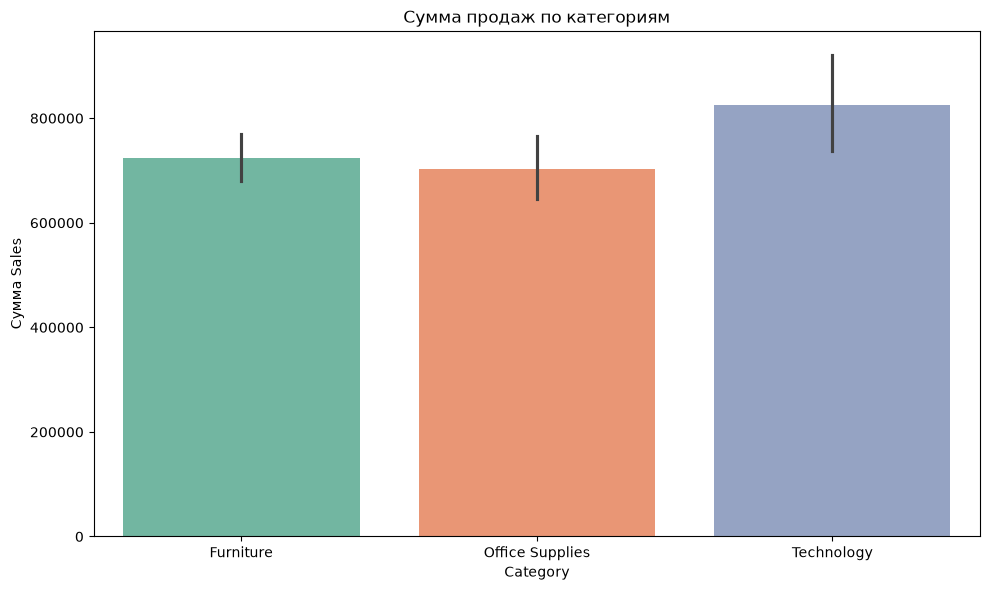

In [3]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='Category', y='Sales', estimator='sum',
            hue='Category', palette='Set2', legend=False)
plt.title('Сумма продаж по категориям')
plt.ylabel('Сумма Sales')
plt.tight_layout()
plt.show()

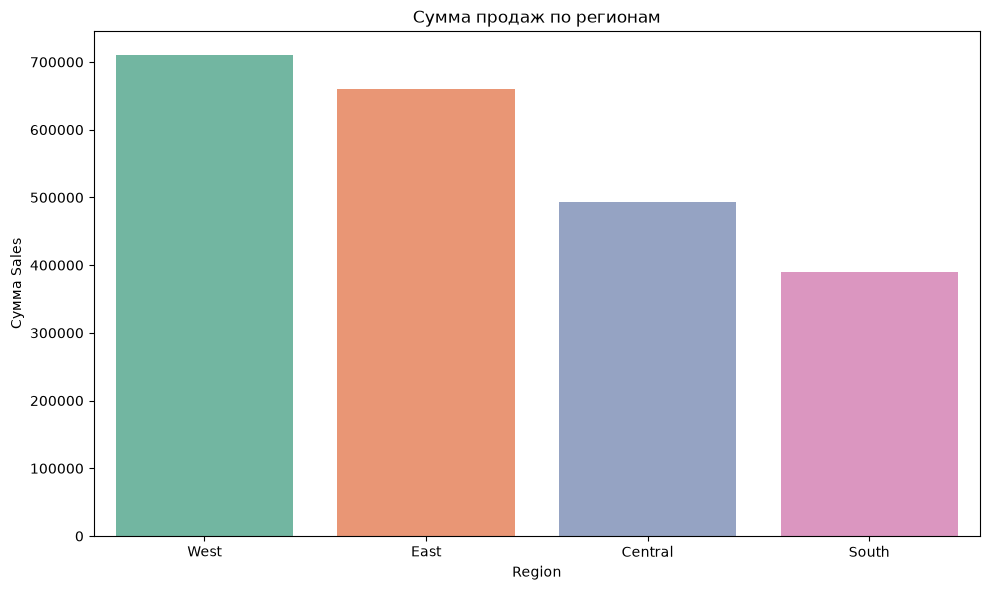

In [4]:
plt.figure(figsize=(10, 6))
region_sales = df.groupby('Region')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
sns.barplot(data=region_sales, x='Region', y='Sales',
            hue='Region', palette='Set2', legend=False)
plt.title('Сумма продаж по регионам')
plt.ylabel('Сумма Sales')
plt.tight_layout()
plt.show()

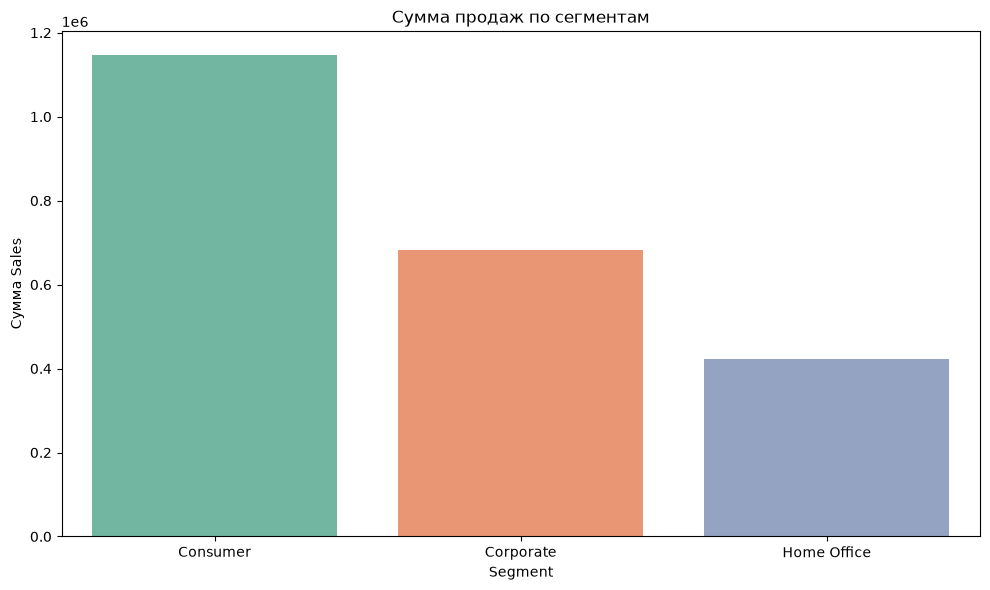

In [5]:
plt.figure(figsize=(10, 6))
segment_sales = df.groupby('Segment')['Sales'].sum().reset_index().sort_values('Sales', ascending=False)
sns.barplot(data=segment_sales, x='Segment', y='Sales',
            hue='Segment', palette='Set2', legend=False)
plt.title('Сумма продаж по сегментам')
plt.ylabel('Сумма Sales')
plt.tight_layout()
plt.show()

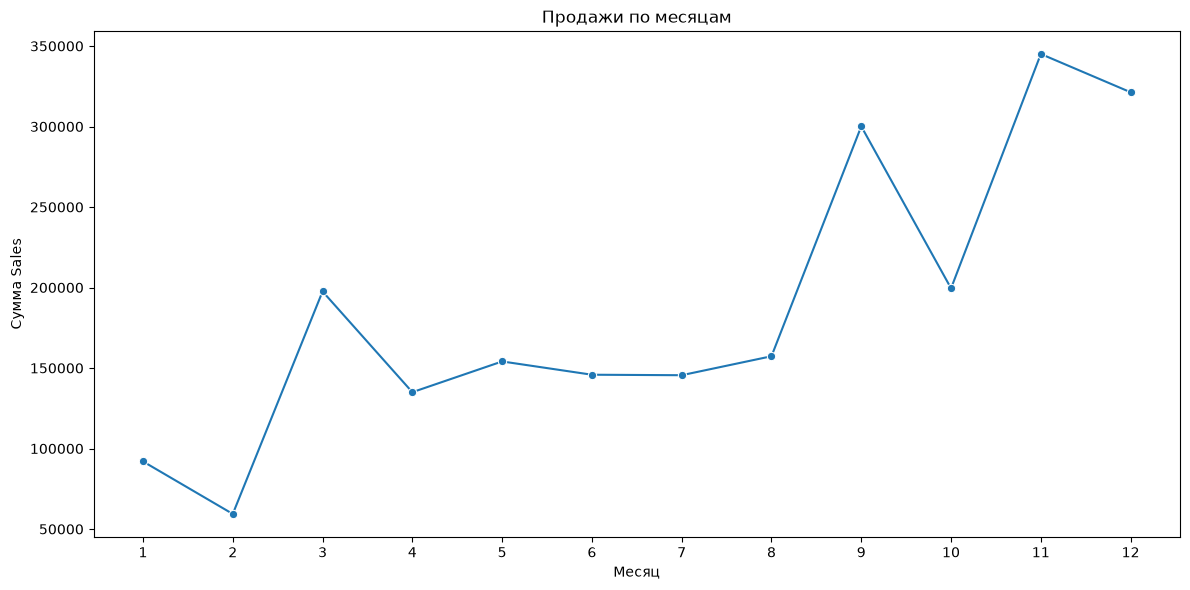

In [6]:
monthly = df.groupby('Order Month')['Sales'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly, x='Order Month', y='Sales', marker='o')
plt.title('Продажи по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Сумма Sales')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

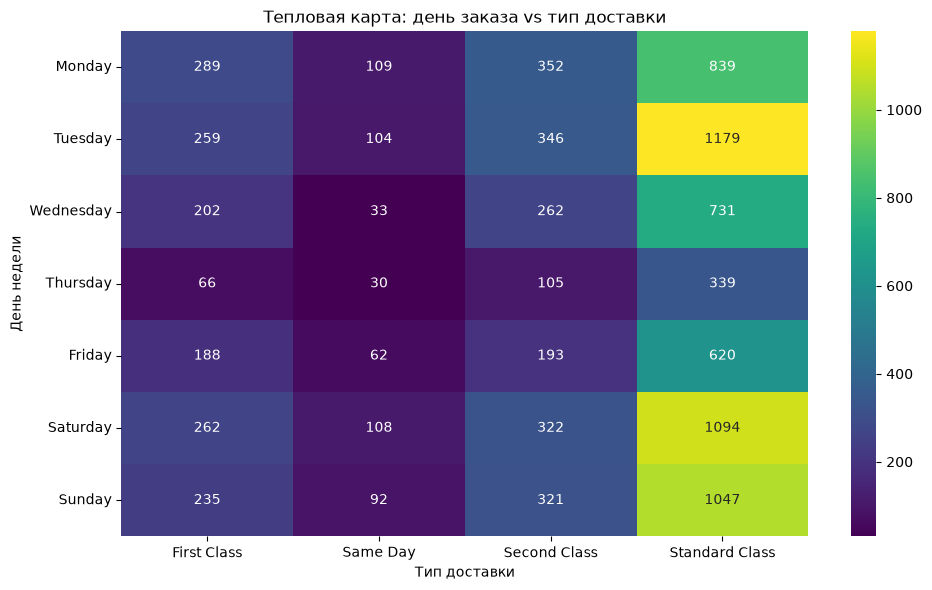

In [7]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Order Day of Week'] = pd.Categorical(df['Order Day of Week'], categories=order, ordered=True)

contingency = pd.crosstab(df['Order Day of Week'], df['Ship Mode'])

plt.figure(figsize=(10, 6))
sns.heatmap(data=contingency, annot=True, fmt='d', cmap='viridis')
plt.title('Тепловая карта: день заказа vs тип доставки')
plt.xlabel('Тип доставки')
plt.ylabel('День недели')
plt.tight_layout()
plt.show()

## Заключение

В ходе анализа датасета Superstore были изучены продажи за период 2015–2018 по категориям, регионам, сегментам и типам доставки.

**Ключевые результаты:**
- Technology - самая прибыльная категория.
- West - лидер по выручке, South - аутсайдер.
- Consumer - лидер по количеству заказов.
- Сезонность выражена визуально, но статистически не подтверждена.
- Тип доставки зависит от дня недели и региона.

**Рекомендации:**
- Фокус на Technology.
- Развитие South и Home Office.
- Оптимизация доставки в понедельник и четверг.
- Стимулирование First Class в Central и South.
- Увеличение запасов в сентябре–декабре.

**Ограничения:**
анализ не учитывает Profit и Discount, так как эти поля отсутствуют в датасете. Рекомендуется дополнить данные для более глубокого анализа.